# Supabase 연결 테스트
**실행 전 준비사항**
1. Supabase 프로젝트 생성 → https://supabase.com
2. `shared/supabase_schema.sql` 을 Supabase SQL Editor에서 실행
3. `.env.example` 을 `.env` 로 복사 후 URL / KEY 입력

In [1]:
%pip install supabase python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append('../..')
sys.path.append('..')
from utils.db import test_connection, insert_posture, fetch_posture_by_date
from utils.db import insert_condition, fetch_condition_by_date
from datetime import datetime

# 1. 연결 확인
test_connection()

[Supabase] ✅ 연결 성공


True

In [3]:
# 2. 테스트 데이터 삽입
import time

ts  = int(time.time())
row = insert_posture(
    timestamp    = ts,
    posture      = "Supine",
    angle        = 72.3,
    capture_type = "regular",
    image_path   = "test/dummy_image.png"
)
print("삽입된 row:", row)

삽입된 row: {'id': 14, 'user_id': 'demo', 'timestamp': 1778460014, 'datetime': '2026-05-11T09:40:14+00:00', 'posture': 'Supine', 'angle': 72.3, 'capture_type': 'regular', 'image_path': 'test/dummy_image.png'}


In [4]:
# 3. 오늘 날짜 데이터 조회
today = datetime.now().strftime("%Y-%m-%d")
rows  = fetch_posture_by_date(today)
print(f"오늘({today}) 데이터 {len(rows)}개:")
for r in rows:
    print(f"  {r['datetime']}  {r['posture']}")

오늘(2026-05-11) 데이터 6개:
  2026-05-11T09:22:52+00:00  Supine
  2026-05-11T09:30:15+00:00  Supine
  2026-05-11T09:35:04+00:00  Supine
  2026-05-11T09:37:37+00:00  Supine
  2026-05-11T09:38:10+00:00  Supine
  2026-05-11T09:40:14+00:00  Supine


In [5]:
# 4. 컨디션 저장 테스트
result = insert_condition(
    log_date      = today,
    refresh_level = 3,
    pain_neck     = True,
    pain_shoulder = False,
    pain_back     = False,
    memo          = "테스트 입력"
)
print("컨디션 저장:", result)

컨디션 저장: {'id': 2, 'user_id': 'demo', 'date': '2026-05-11', 'refreshment': 3, 'pain_neck': True, 'pain_back': False, 'pain_shoulder': False, 'notes': None, 'created_at': '2026-05-11T00:35:06.765591+00:00'}


In [6]:
# 5. 컨디션 조회
cond = fetch_condition_by_date(today)
print("컨디션 조회:", cond)

컨디션 조회: {'id': 2, 'user_id': 'demo', 'date': '2026-05-11', 'refreshment': 3, 'pain_neck': True, 'pain_back': False, 'pain_shoulder': False, 'notes': None, 'created_at': '2026-05-11T00:35:06.765591+00:00'}


## Storage 테스트
이미지 업로드 → 공개 URL → DB 저장까지 한번에 확인합니다  
**사전 준비**: Supabase 대시보드 → Storage → `sleep-images` 버킷 생성 (Public ON)

In [8]:
# 6. 더미 이미지로 Storage 업로드 테스트
import cv2
import numpy as np
from pathlib import Path
from utils.db import upload_image, insert_posture

# 테스트용 더미 이미지 생성
dummy_dir  = Path("../sleep_frames/test")
dummy_dir.mkdir(parents=True, exist_ok=True)
dummy_path = str(dummy_dir / f"{int(time.time())}_regular_color.png")

dummy_img  = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.putText(dummy_img, "Storage Test",
            (180, 240), cv2.FONT_HERSHEY_SIMPLEX,
            1.5, (100, 220, 100), 3)
cv2.imwrite(dummy_path, dummy_img)
print(f"더미 이미지 생성: {dummy_path}")

# Storage 업로드
public_url = upload_image(dummy_path)
print(f"\n공개 URL: {public_url}")
print("\n위 URL을 브라우저에서 열어서 이미지가 보이면 성공입니다 ✅")

더미 이미지 생성: ../sleep_frames/test/1778460165_regular_color.png
[Storage] ✅ 업로드 완료 → https://wfxnkqaeakjltctgfnju.supabase.co/storage/v1/object/public/sleep-images/test/1778460165_regular_color.png

공개 URL: https://wfxnkqaeakjltctgfnju.supabase.co/storage/v1/object/public/sleep-images/test/1778460165_regular_color.png

위 URL을 브라우저에서 열어서 이미지가 보이면 성공입니다 ✅


In [10]:
# 7. 공개 URL을 포함해서 posture_log에 저장
ts  = int(time.time())
row = insert_posture(
    timestamp    = ts,
    posture      = "Supine",
    angle        = 72.3,
    capture_type = "regular",
    image_path   = dummy_path,   # 로컬 경로 → 자동으로 Storage URL로 변환
    upload       = True          # False면 로컬 경로 그대로 저장
)
print("저장된 row:", row)
print(f"\nimage_path 확인: {row.get('image_path', '')}")
print("https:// 로 시작하면 Storage URL 저장 성공 ✅")

[Storage] ✅ 업로드 완료 → https://wfxnkqaeakjltctgfnju.supabase.co/storage/v1/object/public/sleep-images/test/1778460165_regular_color.png
저장된 row: {'id': 16, 'user_id': 'demo', 'timestamp': 1778460326, 'datetime': '2026-05-11T09:45:26+00:00', 'posture': 'Supine', 'angle': 72.3, 'capture_type': 'regular', 'image_path': 'https://wfxnkqaeakjltctgfnju.supabase.co/storage/v1/object/public/sleep-images/test/1778460165_regular_color.png'}

image_path 확인: https://wfxnkqaeakjltctgfnju.supabase.co/storage/v1/object/public/sleep-images/test/1778460165_regular_color.png
https:// 로 시작하면 Storage URL 저장 성공 ✅


/opt/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON})

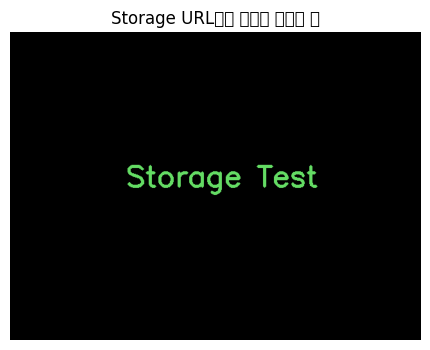

웹 UI에서도 이 URL로 이미지를 바로 표시할 수 있어요


In [11]:
# 8. 저장된 이미지 URL로 바로 불러오기 확인
import matplotlib.pyplot as plt
import urllib.request

image_url = row.get('image_path', '')

if image_url.startswith('http'):
    # URL에서 이미지 다운로드
    req = urllib.request.urlopen(image_url)
    img_array = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    plt.title("Storage URL에서 불러온 이미지 ✅")
    plt.axis('off')
    plt.show()
    print("웹 UI에서도 이 URL로 이미지를 바로 표시할 수 있어요")
else:
    print("❌ URL이 아닌 로컬 경로입니다. Storage 버킷 설정을 확인하세요")